# Giga Meter — Traceroute & Internet Geography

Path-level analysis of the M-Lab traceroute exports committed under
`data/traceroutes/<ISO2>/`. Where the other notebooks ask *how fast* a school's
connection is, this one asks *where its traffic actually goes* — which networks
carry it, through which countries, and what that routing costs in latency.

**Questions answered**
- **Q0** — which direction is the traceroute measured in, and what does that permit?
- **Q1** — how did the measurement panel grow, and is the growth real or a sampling artefact?
- **Q2** — is this a school panel, and which months are comparable?
- **Q3** — who does each ISP buy transit from, and how concentrated is that?
- **Q4** — what does the transit choice cost in latency?
- **Q5** — what is the physical geography of the paths?
- **Annex** — data quality: gaps, unresolved hops, vantage-point concentration

Set the country and months in the loader cell below. Everything downstream reads
from `tr`, so the analysis is the same for any country with committed exports.

---
## Part 0 — Load the traceroute exports

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import sys
import collections
import random
import statistics
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

sys.path.insert(0, 'helpers')
from load_traceroutes import (
    load_traceroutes, manifest, as_path, hop_frame,
    upstream_adjacency, asn_org_lookup, latency_decomposition,
    provider_summary, upstream_concentration,
)

# The Giga design-system style ships macOS font paths; on other platforms
# matplotlib falls back to a default face and logs a findfont miss per glyph.
# Those go through matplotlib's logger rather than warnings, so quiet the logger
# and keep the palette.
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
from giga_chart_style import *

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
COUNTRY_ISO2 = "AL"          # <- country to analyse; anything under data/traceroutes/
MONTHS       = None          # None = every published month; else e.g. ['2026-05','2026-06']

# Per-country parameters. `school_year_months` excludes the summer break, which
# Q2 verifies from the data rather than taking on trust; `primary_site` pins the
# vantage point so latency comparisons share a destination (a list is allowed
# where two sites in one city carry comparable traffic).
COUNTRY_CONFIG = {
    'AL': dict(utc_offset=2,  primary_site='tgd01',
               school_year_months=['2026-03', '2026-04', '2026-05', '2026-06']),
    'BZ': dict(utc_offset=-6, primary_site=['mex01', 'mex04'],
               school_year_months=['2026-02', '2026-03', '2026-04', '2026-05', '2026-06']),
}

_cfg = COUNTRY_CONFIG[COUNTRY_ISO2]
UTC_OFFSET_HOURS   = _cfg['utc_offset']
PRIMARY_SITE       = _cfg['primary_site']
SCHOOL_YEAR_MONTHS = _cfg['school_year_months']
_SITES = [PRIMARY_SITE] if isinstance(PRIMARY_SITE, str) else list(PRIMARY_SITE)

# An ISP-month needs at least this many completed paths to support a claim.
MIN_PATHS = 100

print(f"{COUNTRY_ISO2}: vantage point {_SITES}, "
      f"school-year months {SCHOOL_YEAR_MONTHS}, UTC{UTC_OFFSET_HOURS:+d}")

AL: vantage point ['tgd01'], school-year months ['2026-03', '2026-04', '2026-05', '2026-06'], UTC+2


In [3]:
# =============================================================================
# LOAD — monthly exports -> one frame
# =============================================================================
# load_traceroutes() reads through pyarrow (the exports carry BigQuery 'dbdate'
# pandas metadata that breaks pd.read_parquet) and skips empty months.
tr = load_traceroutes(COUNTRY_ISO2, months=MONTHS)

MAN = manifest(COUNTRY_ISO2)
print(f"Source:    {MAN['source_url']}")
print(f"Bucket:    {MAN.get('bucket', '-')}")
print(f"Retrieved: {MAN.get('retrieved', '-')}\n")

_files = pd.DataFrame(MAN['files'])[['month', 'rows', 'date_min', 'date_max', 'distinct_days']]
display(_files)

print(f"\nLoaded {len(tr):,} traceroutes across {tr['month'].nunique()} months: "
      f"{', '.join(sorted(tr['month'].unique()))}")
_empty = [f['month'] for f in MAN['files'] if f['rows'] == 0]
print("Published but empty:", _empty or 'none')
print("Other countries available: run  python helpers/fetch_traceroutes.py --list")

Source:    https://giga-traceroutes.measurementlab.net/country/al.html
Bucket:    gs://giga_traceroutes/parquet/
Retrieved: 2026-08-29



,month,rows,date_min,date_max,distinct_days
0,2026-02,0,NaN,NaN,0
1,2026-03,6278,2026-03-01,2026-03-31,27
2,2026-04,26009,2026-04-01,2026-04-30,30
3,2026-05,50910,2026-05-01,2026-05-31,30
4,2026-06,40381,2026-06-01,2026-06-30,30
5,2026-07,17337,2026-07-01,2026-07-31,30



Loaded 140,915 traceroutes across 5 months: 2026-03, 2026-04, 2026-05, 2026-06, 2026-07
Published but empty: ['2026-02']
Other countries available: run  python helpers/fetch_traceroutes.py --list


---
## Q0 — Which direction is this measured in?

Everything downstream depends on this, so it is checked rather than assumed.

M-Lab runs the traceroute **from its server towards the client**. If that is
right, every path should *start* in the server's network (`dst_asn`) and the
completed ones should *end* in the client's network (`src_asn`) — not the other
way round. The `is_reaching_dst_asn` flag should then mean "the trace made it
all the way into the client's ASN", the client being the traceroute's target.

This matters for Q3. Because every trace departs the same server, the early hops
describe *M-Lab's* connectivity and are shared by every Albanian ISP. Only the
hops adjacent to the client identify an ISP's own upstream.

In [4]:
# =============================================================================
# Q0 — VERIFY PATH DIRECTION AND THE MEANING OF is_reaching_dst_asn
# =============================================================================
_checks = []
for _m, _g in tr.groupby('month'):
    _first_is_dst = _last_is_src = _n = 0
    _flag_t_ends_src = _flag_f_ends_src = 0
    for _rec in _g[['forward_updated_node_details', 'src_asn', 'dst_asn',
                    'is_reaching_dst_asn']].to_dict('records'):
        _p = as_path(_rec['forward_updated_node_details'])
        if not _p:
            continue
        _n += 1
        _first_is_dst += _p[0] == _rec['dst_asn']
        _last_is_src += _p[-1] == _rec['src_asn']
        if _rec['is_reaching_dst_asn']:
            _flag_t_ends_src += _p[-1] == _rec['src_asn']
        else:
            _flag_f_ends_src += _p[-1] == _rec['src_asn']
    _checks.append({
        'month': _m, 'paths': _n,
        'starts_at_server_%': round(100 * _first_is_dst / _n, 1),
        'ends_at_client_%': round(100 * _last_is_src / _n, 1),
        'flagged & ends at client': _flag_t_ends_src,
        'unflagged & ends at client': _flag_f_ends_src,
    })

display(pd.DataFrame(_checks))
print("Every path starts in the server's ASN, and only flagged paths end in the client's.")
print("=> forward_updated_node_details runs server -> client; the flag means "
      "'reached the client's network'.")

,month,paths,starts_at_server_%,ends_at_client_%,flagged & ends at client,unflagged & ends at client
0,2026-03,6278,100.0,62.8,3944,0
1,2026-04,26009,100.0,61.1,15897,0
2,2026-05,50910,100.0,46.5,23660,0
3,2026-06,40381,100.0,37.8,15280,0
4,2026-07,17337,100.0,36.6,6338,0


Every path starts in the server's ASN, and only flagged paths end in the client's.
=> forward_updated_node_details runs server -> client; the flag means 'reached the client's network'.


---
## Q1 — How did the measurement panel grow?

The Giga Meter campaign in Albania began in **March 2026**, so the first month is
the start of a rollout, not a steady state. The count of distinct access networks
rises sharply after it — but March also holds eight times fewer traces than May,
and a bigger sample finds more networks on its own.

So the growth is rarefied: every month is repeatedly subsampled down to March's
row count and the networks recounted. If the rise survives at equal sample size,
it is real coverage, not sampling luck.

In [5]:
# =============================================================================
# Q1 — PANEL GROWTH, RAW
# =============================================================================
display(provider_summary(tr))
print("HHI is on trace shares (0-10,000). A fall means traces are spread across "
      "more networks;\nit is a property of the panel, not of the market.")

,month,traceroutes,access_asns,hhi,top_asn,top_asn_name,top_share_pct
0,2026-03,6278,10,4811,35047,Abissnet sh.a.,67.7
1,2026-04,26009,34,4567,35047,Abissnet sh.a.,66.9
2,2026-05,50910,42,2039,35047,Abissnet sh.a.,41.9
3,2026-06,40381,39,1254,35047,Abissnet sh.a.,27.8
4,2026-07,17337,37,1200,42313,Albtelecom Sh.a.,22.9


HHI is on trace shares (0-10,000). A fall means traces are spread across more networks;
it is a property of the panel, not of the market.


In [6]:
# =============================================================================
# Q1b — RAREFACTION: does the growth survive at equal sample size?
# =============================================================================
random.seed(0)
_N = int(tr.groupby('month').size().min())     # smallest month = March
_DRAWS = 200

_rows = []
for _m, _g in tr.groupby('month'):
    _asns, _cities = list(_g['src_asn']), [c for c in _g['src_city'] if c]
    _a = [len(set(random.sample(_asns, _N))) for _ in range(_DRAWS)]
    _c = [len(set(random.sample(_cities, _N))) for _ in range(_DRAWS)]
    _rows.append({
        'month': _m, 'traces': len(_g),
        'asns_all': len(set(_asns)),
        f'asns_at_n={_N:,}': f"{statistics.mean(_a):.1f} ± {statistics.stdev(_a):.1f}",
        'cities_all': len(set(_cities)),
        f'cities_at_n={_N:,}': f"{statistics.mean(_c):.1f}",
    })

display(pd.DataFrame(_rows))
print(f"Subsampled to n={_N:,} in every month, so the counts are directly comparable.")
print("The rise holds at equal sample size => real broadening of the panel.")

,month,traces,asns_all,"asns_at_n=6,278",cities_all,"cities_at_n=6,278"
0,2026-03,6278,10,10.0 ± 0.0,6,6.0
1,2026-04,26009,34,31.5 ± 1.1,14,13.6
2,2026-05,50910,42,41.2 ± 0.8,18,17.6
3,2026-06,40381,39,38.9 ± 0.3,18,18.0
4,2026-07,17337,37,36.7 ± 0.5,38,37.3


Subsampled to n=6,278 in every month, so the counts are directly comparable.
The rise holds at equal sample size => real broadening of the panel.


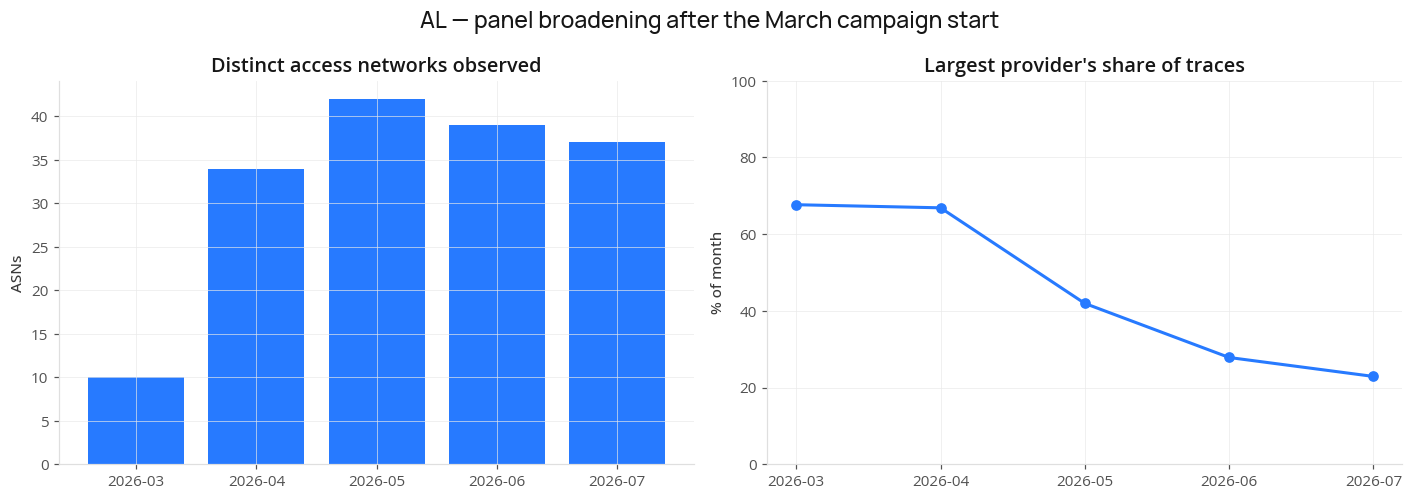

Read this as deployment coverage: more schools in more places came online.
It is NOT evidence that more ISPs entered the market, or that any school changed provider.


In [7]:
# =============================================================================
# Q1c — WHAT THE ROLLOUT LOOKED LIKE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

_ps = provider_summary(tr)
axes[0].bar(_ps['month'], _ps['access_asns'], color=GIGA_BLUE)
axes[0].set_title('Distinct access networks observed')
axes[0].set_ylabel('ASNs')

_share = (tr.groupby(['month', 'src_asn']).size()
            .groupby(level=0).apply(lambda s: 100 * s.max() / s.sum()))
axes[1].plot(_share.index, _share.values, marker='o', color=GIGA_BLUE, linewidth=2)
axes[1].set_title("Largest provider's share of traces")
axes[1].set_ylabel('% of month')
axes[1].set_ylim(0, 100)

for _ax in axes:
    _ax.tick_params(axis='x', rotation=0)
fig.suptitle(f'{COUNTRY_ISO2} — panel broadening after the March campaign start')
plt.tight_layout(); plt.show()

print("Read this as deployment coverage: more schools in more places came online.")
print("It is NOT evidence that more ISPs entered the market, or that any school "
      "changed provider.")

---
## Q2 — Is this a school panel, and which months compare?

The publisher's methodology names a filter — *"We filter each dataset to known
school IP ranges"* — but applies it **downstream of these files**. The country
page labels the parquet "everything fetched" and reports the filtered subset
separately: Belize July 2026 is 889 school measurements from 28 school IPs,
against 1,316 rows and 204 client IPs in the file itself.

So this notebook runs on NDT clients in the country, not on schools. The filter
cannot be reproduced here — the school IP ranges are Giga's and are not in the
data — and the way in is the `id` column, the NDT UUID that also keys the Giga
Meter measurements.

What the timing establishes is that the population is school-*dominated*, which
is consistent with roughly two thirds of rows surviving the filter, and it dates
the series against the school calendar — which is what decides whether one month
can be compared with another. Schools and households have opposite clocks:
school traffic peaks in the morning and decays through the teaching day and all
but disappears at weekends, where residential traffic climbs through the
evening.


In [8]:
# =============================================================================
# Q2 — DIURNAL AND WEEKLY SIGNATURE
# =============================================================================
tr['local_hour'] = (tr['window_start'].dt.hour + UTC_OFFSET_HOURS) % 24
tr['dow'] = tr['window_start'].dt.dayofweek          # 0 = Monday

_wd = tr[tr['dow'] < 5]
_school_window = _wd[(_wd['local_hour'] >= 8) & (_wd['local_hour'] <= 15)]
_uniform = 100 * (8 * 5) / (24 * 7)

print(f"Weekday 08:00-15:59 local holds {100 * len(_school_window) / len(tr):.1f}% of all traces")
print(f"A uniform clock would put {_uniform:.1f}% there -> "
      f"{(100 * len(_school_window) / len(tr)) / _uniform:.1f}x concentration\n")

_dow = 100 * tr.groupby('dow').size() / len(tr)
print("Share of traces by day:")
for _i, _name in enumerate(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']):
    print(f"   {_name}  {_dow.get(_i, 0):4.1f}%")

Weekday 08:00-15:59 local holds 63.1% of all traces
A uniform clock would put 23.8% there -> 2.6x concentration

Share of traces by day:
   Mon  17.4%
   Tue  18.1%
   Wed  17.4%
   Thu  16.9%
   Fri  16.7%
   Sat   7.0%
   Sun   6.5%


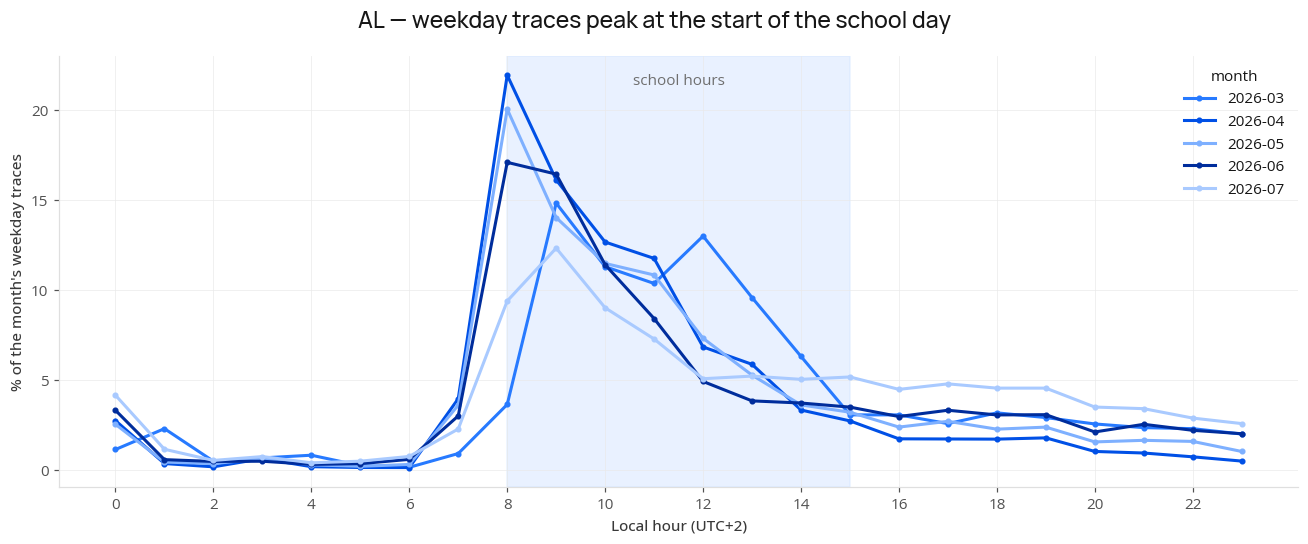

,month,traces,weekday 08-16 %,weekend %,peak hour
0,2026-03,6278,61.6,14.5,9
1,2026-04,26009,75.5,7.1,8
2,2026-05,50910,65.7,13.3,8
3,2026-06,40381,58.2,16.1,8
4,2026-07,17337,48.6,17.0,9


In [9]:
# =============================================================================
# Q2b — THE CLOCK, MONTH BY MONTH
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 5))
for _m, _g in tr[tr['dow'] < 5].groupby('month'):
    _h = 100 * _g.groupby('local_hour').size() / len(_g)
    _h = _h.reindex(range(24), fill_value=0)
    ax.plot(_h.index, _h.values, marker='o', markersize=3, linewidth=2, label=_m)

ax.axvspan(8, 15, color=GIGA_PRIMARY[100], alpha=0.5, zorder=0)
ax.annotate('school hours', xy=(11.5, ax.get_ylim()[1] * 0.93), ha='center',
            color=GIGA_GREY[600], fontsize=10)
ax.set_xlabel(f'Local hour (UTC+{UTC_OFFSET_HOURS})')
ax.set_ylabel('% of the month\'s weekday traces')
ax.set_xticks(range(0, 24, 2))
ax.legend(title='month')
fig.suptitle(f'{COUNTRY_ISO2} — weekday traces peak at the start of the school day')
plt.tight_layout(); plt.show()

_rows = []
for _m, _g in tr.groupby('month'):
    _w = _g[_g['dow'] < 5]
    _rows.append({
        'month': _m, 'traces': len(_g),
        'weekday 08-16 %': round(100 * len(_w[(_w['local_hour'] >= 8) &
                                              (_w['local_hour'] <= 15)]) / len(_g), 1),
        'weekend %': round(100 * len(_g[_g['dow'] >= 5]) / len(_g), 1),
        'peak hour': int(_w.groupby('local_hour').size().idxmax()),
    })
display(pd.DataFrame(_rows))

In [10]:
# =============================================================================
# Q2c — THE SCHOOL CALENDAR ENDS THE COMPARABLE SERIES
# =============================================================================
# If these are schools, volume should fall away as term ends rather than track
# anything about the network.
for _m in sorted(tr['month'].unique())[-2:]:
    _g = tr[tr['month'] == _m]
    _daily = _g.groupby(_g['partition_date'].dt.day).size()
    _h1, _h2 = _daily[_daily.index <= 15].mean(), _daily[_daily.index > 15].mean()
    print(f"{_m}: days 1-15 {_h1:,.0f}/day | days 16-31 {_h2:,.0f}/day  "
          f"({100 * _h2 / _h1 - 100:+.0f}%)")

print(f"\nThe last month loses both its shape and its volume as the school year ends.")
print(f"Comparable months for anything trend-like: {SCHOOL_YEAR_MONTHS}")
print("A trend line drawn through the final month measures the summer holiday.")

2026-06: days 1-15 1,399/day | days 16-31 1,293/day  (-8%)
2026-07: days 1-15 836/day | days 16-31 352/day  (-58%)

The last month loses both its shape and its volume as the school year ends.
Comparable months for anything trend-like: ['2026-03', '2026-04', '2026-05', '2026-06']
A trend line drawn through the final month measures the summer holiday.


---
## Q3 — Who does each ISP buy transit from?

The temptation is to count every non-domestic network on the path and call the
frequent ones "the upstreams". Q0 showed why that fails: all traces leave the
same server, so its transit providers appear on nearly every Albanian ISP's
paths and look like a shared dependency that does not exist.

Both are computed below, because the difference between them is the method.

In [11]:
# =============================================================================
# Q3 — THE NAIVE COUNT (shown to be discarded)
# =============================================================================
_naive = collections.Counter()
_orgs = asn_org_lookup(tr)
for _rec in tr[['forward_updated_node_details', 'src_asn', 'dst_asn']].to_dict('records'):
    for _asn in set(as_path(_rec['forward_updated_node_details'])):
        if _asn not in (_rec['src_asn'], _rec['dst_asn']):
            _naive[_asn] += 1

print("Networks appearing anywhere on the path (share of all traces):")
for _asn, _n in _naive.most_common(6):
    print(f"   {_orgs.get(_asn, f'AS{_asn}')[:44]:46s} {100 * _n / len(tr):5.1f}%")
print("\nThis mostly describes the M-Lab server's own transit. It is the same for "
      "every\nAlbanian ISP, so it cannot distinguish one provider's upstream from "
      "another's.")

Networks appearing anywhere on the path (share of all traces):
   Hrvatski Telekom d.d.                           91.0%
   Cogent Communications, LLC                      75.9%
   Vodafone Group PLC                              17.6%
   Arelion Sweden AB                               11.4%
   Albanian Telecommunications Union SH. P.K.       3.4%
   ONE ALBANIA SH.A.                                3.2%

This mostly describes the M-Lab server's own transit. It is the same for every
Albanian ISP, so it cannot distinguish one provider's upstream from another's.


In [12]:
# =============================================================================
# Q3b — THE UPSTREAM ADJACENT TO THE CLIENT
# =============================================================================
# The AS one hop before the client's own network: the transit relationship the
# access ISP actually holds. Completed paths only.
up = upstream_adjacency(tr)
print(f"{len(up):,} completed paths carry a visible upstream "
      f"({100 * len(up) / len(tr):.0f}% of all traces)\n")

conc = upstream_concentration(up, min_paths=MIN_PATHS)
display(conc[conc['month'].isin(SCHOOL_YEAR_MONTHS)])

65,186 completed paths carry a visible upstream (46% of all traces)



,month,client_asn,client_asn_name,completed_paths,upstreams,hhi,top_upstream_asn,top_upstream_org,top_upstream_share_pct
0,2026-03,35047,Abissnet sh.a.,3435,3,5170,174.0,"Cogent Communications, LLC",59.4
1,2026-03,50616,Telekom Albania SH.A,402,2,8834,1299.0,Arelion Sweden AB,93.8
2,2026-04,35047,Abissnet sh.a.,14881,3,9271,174.0,"Cogent Communications, LLC",96.2
3,2026-04,50616,Telekom Albania SH.A,239,1,10000,1299.0,Arelion Sweden AB,100.0
4,2026-04,209839,Luva Group Sh.p.k.,183,1,10000,198279.0,Albanian Telecommunications Union SH. P.K.,100.0
5,2026-05,35047,Abissnet sh.a.,18371,3,9522,174.0,"Cogent Communications, LLC",97.6
6,2026-05,50616,Telekom Albania SH.A,1141,2,9673,1299.0,Arelion Sweden AB,98.3
7,2026-05,209839,Luva Group Sh.p.k.,537,2,9889,198279.0,Albanian Telecommunications Union SH. P.K.,99.4
8,2026-05,57388,I.B.C shpk,459,3,9198,8585.0,Crnogorski Telekom a.d.Podgorica,95.9
9,2026-05,42313,Albtelecom Sh.a.,450,2,9651,174.0,"Cogent Communications, LLC",98.2


ISP-months with the top upstream at >=90% of paths: 24 of 34
ISP-months where only one upstream is ever seen:     7 of 34

Country-level transit mix (trace-weighted, school-year months):
   Cogent Communications, LLC                      76.3%
   Arelion Sweden AB                               11.5%
   Albanian Telecommunications Union SH. P.K.       2.8%
   Crnogorski Telekom a.d.Podgorica                 2.4%
   ONE ALBANIA SH.A.                                1.9%
   Vodafone Group PLC                               1.3%
   Hurricane Electric LLC                           1.0%
   Drustvo za telekomunikacije "MTEL" DOO           0.5%

   HHI across upstreams: 5,974   (>2,500 is 'highly concentrated' under the usual merger guidelines)


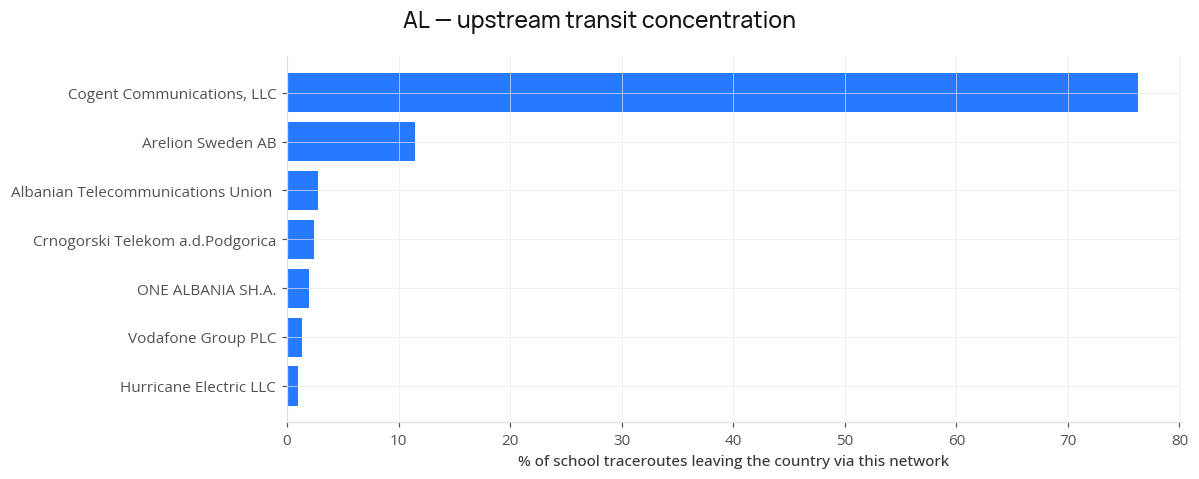

In [13]:
# =============================================================================
# Q3c — HOW SINGLE-HOMED IS THE SECTOR?
# =============================================================================
_c = conc[conc['month'].isin(SCHOOL_YEAR_MONTHS)]
print(f"ISP-months with the top upstream at >=90% of paths: "
      f"{(_c['top_upstream_share_pct'] >= 90).sum()} of {len(_c)}")
print(f"ISP-months where only one upstream is ever seen:     "
      f"{(_c['upstreams'] == 1).sum()} of {len(_c)}\n")

_j = tr.merge(up[['id', 'upstream_org']], on='id')
_j = _j[_j['month'].isin(SCHOOL_YEAR_MONTHS)]
_country = 100 * _j['upstream_org'].value_counts(normalize=True)

print("Country-level transit mix (trace-weighted, school-year months):")
for _org, _pct in _country.head(8).items():
    print(f"   {_org[:44]:46s} {_pct:5.1f}%")
print(f"\n   HHI across upstreams: {((_country) ** 2).sum():,.0f}"
      "   (>2,500 is 'highly concentrated' under the usual merger guidelines)")

fig, ax = plt.subplots(figsize=(11, 4.4))
_top = _country.head(7)[::-1]
ax.barh([o[:34] for o in _top.index], _top.values, color=GIGA_BLUE)
ax.set_xlabel('% of school traceroutes leaving the country via this network')
fig.suptitle(f'{COUNTRY_ISO2} — upstream transit concentration')
plt.tight_layout(); plt.show()

---
## Q4 — What does the transit choice cost?

Q3 established that most schools sit behind one upstream. The policy question is
whether that matters for the classroom, and the data contains an unusually clean
test of it.

The destination is held fixed (one M-Lab server), so every school below is
reaching the *same* endpoint. Where two ISPs in the same city differ only in who
carries their traffic, the difference in latency is attributable to the route.
The strongest case is a single ISP observed on two different upstreams: the
access network, the city and the destination are all identical.

In [14]:
# =============================================================================
# Q4 — LATENCY AND PATH LENGTH BY (ISP, UPSTREAM)
# =============================================================================
_fix = tr.merge(up[['id', 'upstream_asn', 'upstream_org']], on='id')
_fix = _fix[_fix['dst_site'].isin(_SITES) & _fix['month'].isin(SCHOOL_YEAR_MONTHS)]

pairs = (_fix.groupby(['src_asn_name', 'upstream_org'])
             .agg(paths=('id', 'size'),
                  median_rtt_ms=('ndt_rtt', 'median'),
                  median_path_km=('forward_distance', 'median'),
                  median_mbps=('ndt_throughput', 'median'))
             .reset_index())
pairs = (pairs[pairs['paths'] >= MIN_PATHS]
         .sort_values('median_rtt_ms').reset_index(drop=True))
pairs.columns = ['isp', 'upstream', 'paths', 'median_rtt_ms', 'median_path_km', 'median_mbps']

display(pairs.style.format({'median_rtt_ms': '{:.1f}', 'median_path_km': '{:,.0f}',
                            'median_mbps': '{:.1f}', 'paths': '{:,}'}))
print(f'Destination held fixed at {_SITES}. Same endpoint for every row.')

,isp,upstream,paths,median_rtt_ms,median_path_km,median_mbps
0,I.B.C shpk,Crnogorski Telekom a.d.Podgorica,972,4.0,56,69.2
1,Mobitel Communication Sh.p.k,Crnogorski Telekom a.d.Podgorica,343,4.2,160,87.9
2,ITCOM Shpk,"Drustvo za telekomunikacije ""MTEL"" DOO",287,13.7,"1,193",94.2
3,Abissnet sh.a.,"Cogent Communications, LLC","41,342",26.6,"1,250",74.5
4,Albanian Telecommunications Union SH. P.K.,"Cogent Communications, LLC",664,26.7,"1,313",47.8
5,ADA Holding - ADA AIR sh.p.k.,Albanian Telecommunications Union SH. P.K.,209,26.9,"1,413",62.2
6,Albtelecom Sh.a.,"Cogent Communications, LLC",957,29.1,"1,341",62.7
7,ABCOM Shpk,Vodafone Albania Sh.A.,215,29.4,350,33.9
8,Tele.Co.Albania SHPK,Albanian Telecommunications Union SH. P.K.,100,32.9,"1,331",27.7
9,ABCOM Shpk,Vodafone Group PLC,324,35.6,"1,589",13.3


Destination held fixed at ['tgd01']. Same endpoint for every row.


In [15]:
# =============================================================================
# Q4b — THE WITHIN-ISP CONTRAST
# =============================================================================
# Any ISP seen on more than one upstream controls for the access network itself.
_multi = pairs.groupby('isp').filter(lambda g: len(g) > 1)

if _multi.empty:
    print('No ISP is observed on more than one upstream at this threshold.')
else:
    for _isp, _g in _multi.groupby('isp'):
        _g = _g.sort_values('median_rtt_ms')
        _lo, _hi = _g.iloc[0], _g.iloc[-1]
        print(f"{_isp}")
        for _, _r in _g.iterrows():
            print(f"   via {_r['upstream'][:34]:36s} {_r['median_rtt_ms']:5.1f} ms  "
                  f"{_r['median_path_km']:>7,.0f} km   {_r['median_mbps']:5.1f} Mbps  "
                  f"(n={_r['paths']:,})")
        print(f"   -> same network, same destination: "
              f"{_hi['median_rtt_ms'] / _lo['median_rtt_ms']:.1f}x the latency "
              f"on the slower upstream\n")

ABCOM Shpk
   via Vodafone Albania Sh.A.                29.4 ms      350 km    33.9 Mbps  (n=215)
   via Vodafone Group PLC                    35.6 ms    1,589 km    13.3 Mbps  (n=324)
   -> same network, same destination: 1.2x the latency on the slower upstream

Abissnet sh.a.
   via Cogent Communications, LLC            26.6 ms    1,250 km    74.5 Mbps  (n=41,342)
   via Arelion Sweden AB                     65.2 ms    3,001 km    75.5 Mbps  (n=2,623)
   -> same network, same destination: 2.4x the latency on the slower upstream

Tele.Co.Albania SHPK
   via Albanian Telecommunications Union     32.9 ms    1,331 km    27.7 Mbps  (n=100)
   via ONE ALBANIA SH.A.                     37.3 ms    1,348 km    78.8 Mbps  (n=213)
   -> same network, same destination: 1.1x the latency on the slower upstream



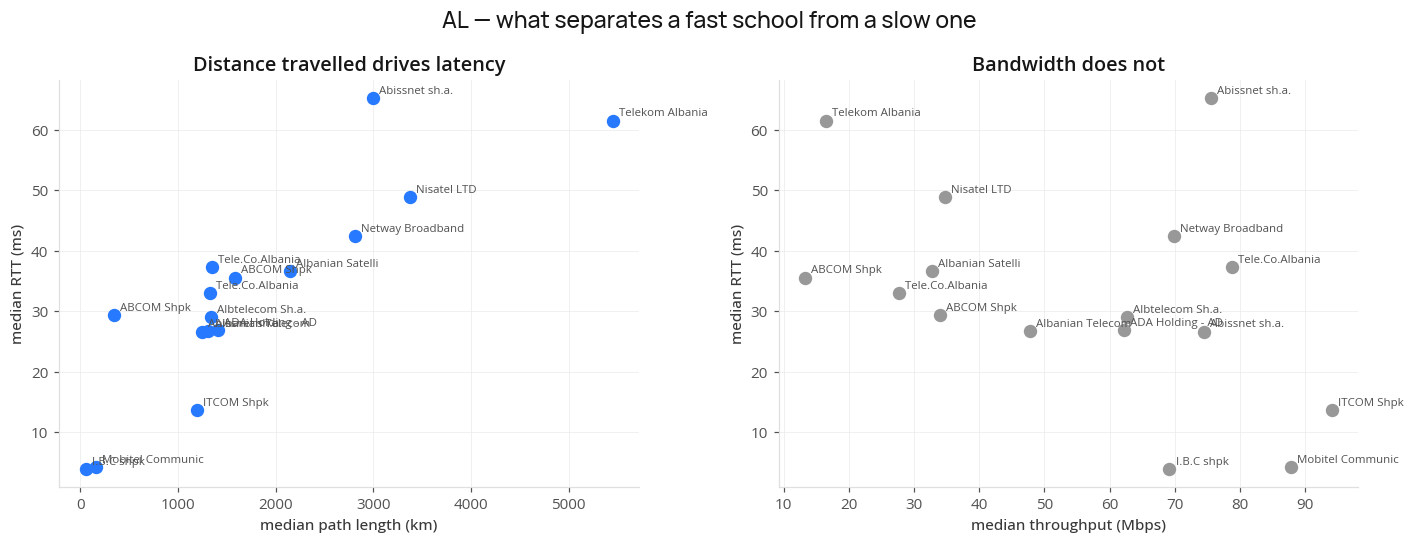

Correlation of median RTT with path km : +0.86
Correlation of median RTT with Mbps    : -0.44

Procurement specifies Mbps. The right-hand panel is what that buys you.


In [16]:
# =============================================================================
# Q4c — LATENCY IS A ROUTING OUTCOME, NOT A BANDWIDTH ONE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(pairs['median_path_km'], pairs['median_rtt_ms'],
                s=60, color=GIGA_BLUE, zorder=3)
for _, _r in pairs.iterrows():
    axes[0].annotate(_r['isp'][:16], (_r['median_path_km'], _r['median_rtt_ms']),
                     fontsize=7.5, xytext=(4, 3), textcoords='offset points',
                     color=GIGA_GREY[700])
axes[0].set_xlabel('median path length (km)')
axes[0].set_ylabel('median RTT (ms)')
axes[0].set_title('Distance travelled drives latency')

axes[1].scatter(pairs['median_mbps'], pairs['median_rtt_ms'],
                s=60, color=GIGA_GREY[500], zorder=3)
for _, _r in pairs.iterrows():
    axes[1].annotate(_r['isp'][:16], (_r['median_mbps'], _r['median_rtt_ms']),
                     fontsize=7.5, xytext=(4, 3), textcoords='offset points',
                     color=GIGA_GREY[700])
axes[1].set_xlabel('median throughput (Mbps)')
axes[1].set_ylabel('median RTT (ms)')
axes[1].set_title('Bandwidth does not')

fig.suptitle(f'{COUNTRY_ISO2} — what separates a fast school from a slow one')
plt.tight_layout(); plt.show()

print(f"Correlation of median RTT with path km : {pairs['median_rtt_ms'].corr(pairs['median_path_km']):+.2f}")
print(f"Correlation of median RTT with Mbps    : {pairs['median_rtt_ms'].corr(pairs['median_mbps']):+.2f}")
print("\nProcurement specifies Mbps. The right-hand panel is what that buys you.")

---
## Q5 — The physical geography of the paths

Latency is distance plus the detours routing imposes. This section reads the
countries a path crosses and how far it travels, against how far it would need
to travel if it went directly.

In [17]:
# =============================================================================
# Q5 — COUNTRIES CROSSED, AND HOW FAR THE TRAFFIC ACTUALLY GOES
# =============================================================================
def _hops(h):
    return h if h is not None else []

_geo = tr[tr['is_reaching_dst_asn'].fillna(False) & tr['dst_site'].isin(_SITES)]

for _m in SCHOOL_YEAR_MONTHS:
    _g = _geo[_geo['month'] == _m]
    if _g.empty:
        continue
    _cc = collections.Counter()
    for _h in _g['forward_updated_node_details']:
        for _c in {x['cc'] for x in _hops(_h) if x['cc']}:
            _cc[_c] += 1
    print(f"{_m}  (n={len(_g):,} completed paths)")
    print("   countries on path:",
          ', '.join(f"{_c} {100 * _v / len(_g):.0f}%" for _c, _v in _cc.most_common(7)))
    print(f"   median path {_g['forward_distance'].median():,.0f} km "
          f"| median RTT {_g['ndt_rtt'].median():.1f} ms\n")

2026-03  (n=3,757 completed paths)
   countries on path: HR 100%, AL 100%, ME 100%, RS 56%, AT 44%, IT 35%, DE 33%
   median path 2,254 km | median RTT 52.8 ms



2026-04  (n=15,135 completed paths)


   countries on path: ME 100%, AL 100%, HR 99%, RS 94%, AT 5%, BG 3%, IT 2%
   median path 1,250 km | median RTT 43.9 ms

2026-05  (n=22,611 completed paths)
   countries on path: ME 100%, AL 100%, HR 97%, RS 87%, BG 11%, AT 7%, SE 5%
   median path 1,250 km | median RTT 26.7 ms



2026-06  (n=14,566 completed paths)
   countries on path: ME 100%, AL 100%, HR 95%, RS 69%, AT 20%, IT 17%, BG 13%
   median path 1,280 km | median RTT 27.4 ms



In [18]:
# =============================================================================
# Q5b — THE ROUTE EACH UPSTREAM TAKES
# =============================================================================
_fixgeo = _fix[_fix['is_reaching_dst_asn'].fillna(False)]
_pairs_top = pairs.head(8)

for _, _r in _pairs_top.iterrows():
    _s = _fixgeo[(_fixgeo['src_asn_name'] == _r['isp']) &
                 (_fixgeo['upstream_org'] == _r['upstream'])]
    if _s.empty:
        continue
    _cc = collections.Counter()
    for _h in _s['forward_updated_node_details']:
        for _c in {x['cc'] for x in _hops(_h) if x['cc']}:
            _cc[_c] += 1
    _route = ', '.join(f"{_c} {100 * _v / len(_s):.0f}%"
                       for _c, _v in _cc.most_common(6))
    print(f"{_r['isp'][:28]:30s} via {_r['upstream'][:26]:28s} "
          f"{_r['median_rtt_ms']:5.1f} ms")
    print(f"   {_route}\n")

print("The short paths stay regional. The long ones transit western and northern "
      "Europe\nto reach a server the schools could almost drive to.")

I.B.C shpk                     via Crnogorski Telekom a.d.Pod     4.0 ms
   ME 100%, AL 100%

Mobitel Communication Sh.p.k   via Crnogorski Telekom a.d.Pod     4.2 ms
   ME 100%, AL 100%

ITCOM Shpk                     via Drustvo za telekomunikacij    13.7 ms
   HR 100%, RS 100%, ME 100%, AL 95%



Abissnet sh.a.                 via Cogent Communications, LLC    26.6 ms
   ME 100%, AL 100%, HR 100%, RS 99%, BG 2%, GR 2%

Albanian Telecommunications    via Cogent Communications, LLC    26.7 ms
   HR 100%, ME 100%, AL 100%, RS 100%, SK 0%, HU 0%

ADA Holding - ADA AIR sh.p.k   via Albanian Telecommunication    26.9 ms
   HR 100%, RS 100%, ME 100%, AL 100%, BG 1%, GR 1%

Albtelecom Sh.a.               via Cogent Communications, LLC    29.1 ms
   HR 100%, RS 100%, ME 100%, AL 100%, SK 0%, HU 0%

ABCOM Shpk                     via Vodafone Albania Sh.A.        29.4 ms
   AL 100%, ME 100%, HR 29%, BG 28%, AT 17%, RS 12%

The short paths stay regional. The long ones transit western and northern Europe
to reach a server the schools could almost drive to.


In [19]:
# =============================================================================
# Q5c — DOMESTIC AND REGIONAL INTERCONNECTION
# =============================================================================
hops = hop_frame(tr[tr['month'].isin(SCHOOL_YEAR_MONTHS)])
_ixp = hops[hops['hop_ixp'].notna() & (hops['hop_ixp'] != 'None')]

print(f"Hops observed: {len(hops):,}")
print(f"Hops crossing a known IXP: {len(_ixp):,} ({100 * len(_ixp) / len(hops):.4f}%)")
if not _ixp.empty:
    display(_ixp['hop_ixp'].value_counts().head())
print("\nEffectively no exchange-point interconnection appears on these paths. "
      "That is the\nmechanism behind Q4: with nowhere regional to hand traffic "
      "off, it goes to a\nTier-1 and travels.")

Hops observed: 1,485,049
Hops crossing a known IXP: 83 (0.0056%)


hop_ixp
SOX_Serbia    76
VIX            7
Name: count, dtype: int64


Effectively no exchange-point interconnection appears on these paths. That is the
mechanism behind Q4: with nowhere regional to hand traffic off, it goes to a
Tier-1 and travels.


---
## Q6 — Latency decomposition and loss

The published methodology summarises *"path length, exchange-point crossings,
transit-country dependency, latency decomposition, loss, and performance over
time"*. Q4 and Q5 cover the first three; this section adds the last three.

Hop RTTs are cumulative from the server, so the gap between consecutive
responding hops is that link's contribution to the total. Splitting those links
by whether both endpoints sit in the country separates the latency a national
operator or regulator can act on from the latency that accrues abroad.

Read the international share against where the test server is. For a country
with no domestic M-Lab server the international part is guaranteed non-zero, so
the number that carries meaning is the *domestic* millisecond count: it says how
much of the delay is home-grown, and how little room a purely domestic
intervention has.

In [20]:
# =============================================================================
# Q6 — HOW MUCH OF THE DELAY IS DOMESTIC?
# =============================================================================
decomp = latency_decomposition(tr, COUNTRY_ISO2)

print(f"Completed paths decomposed: {len(decomp):,}\n")
print(f"median domestic segment      {decomp['domestic_ms'].median():8.2f} ms")
print(f"median international segment {decomp['international_ms'].median():8.2f} ms")
print(f"median international share   {decomp['international_pct'].median():8.1f}%")
print(f"median measured RTT          {decomp['ndt_rtt'].median():8.2f} ms")
print(f"median packet loss           {100 * decomp['loss_rate'].median():8.2f}%")

_domestic_server = (tr['src_country'] == tr['dst_country']).mean()
print(f"\nShare of traces to a domestic test server: {100 * _domestic_server:.1f}%")
if _domestic_server < 0.05:
    print("No domestic server: the international segment is non-zero by "
          "construction,\nso read the domestic millisecond count, not the share.")

Completed paths decomposed: 65,186

median domestic segment          1.05 ms
median international segment    34.38 ms
median international share       96.7%
median measured RTT             32.34 ms
median packet loss               4.23%

Share of traces to a domestic test server: 0.0%
No domestic server: the international segment is non-zero by construction,
so read the domestic millisecond count, not the share.


,isp,paths,domestic_ms,international_ms,intl_pct,rtt_ms,loss_pct
9,I.B.C shpk,"1,489",0.00,5.95,100.0,4.1,0.05
12,Mobitel Communication Sh.p.k,417,0.00,3.23,100.0,4.4,0.94
10,ITCOM Shpk,422,0.00,19.19,100.0,13.6,0.02
1,ADA Holding - ADA AIR sh.p.k.,319,0.63,26.06,97.9,27.3,1.85
6,Albanian Telecommunications Union SH. P.K.,887,0.78,24.72,97.2,27.5,5.54
3,Abissnet sh.a.,"49,298",1.23,28.67,96.1,27.7,4.90
7,Albtelecom Sh.a.,"1,620",3.17,33.34,89.9,32.7,4.81
0,ABCOM Shpk,629,0.00,29.97,100.0,33.9,2.36
19,Tele.Co.Albania SHPK,547,1.69,33.94,95.7,36.3,1.16
5,Albanian Satellite Communications sh.p.k.,823,2.09,40.69,95.5,36.5,2.80


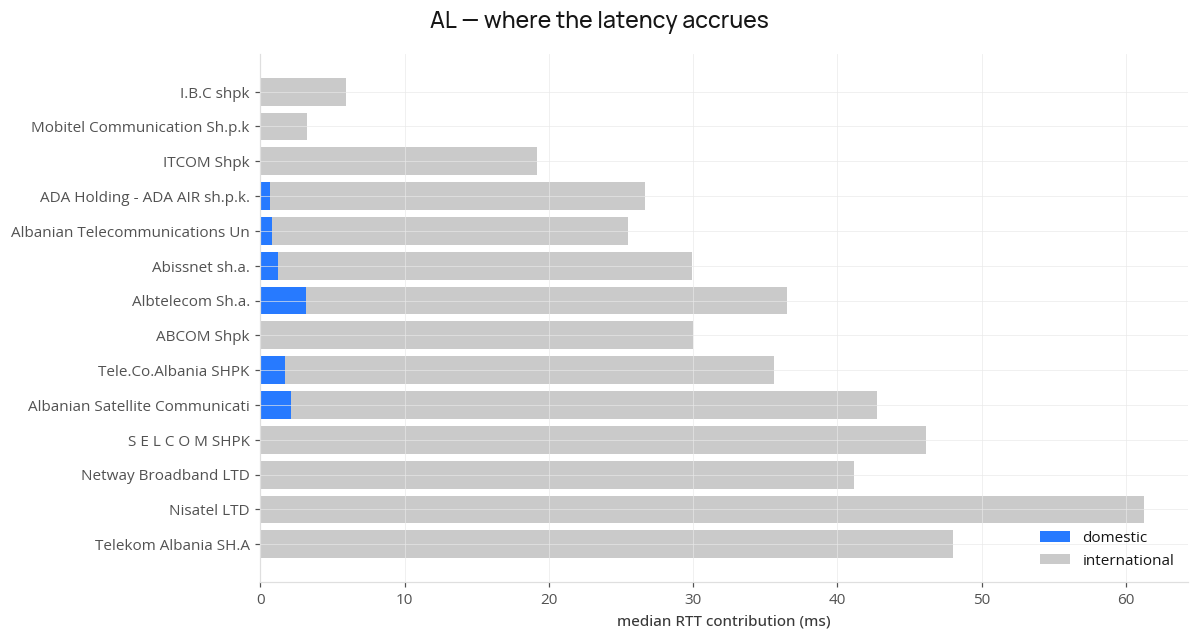

In [21]:
# =============================================================================
# Q6b — DECOMPOSITION BY ISP
# =============================================================================
_by_isp = (decomp.groupby('isp')
                 .agg(paths=('id', 'size'),
                      domestic_ms=('domestic_ms', 'median'),
                      international_ms=('international_ms', 'median'),
                      intl_pct=('international_pct', 'median'),
                      rtt_ms=('ndt_rtt', 'median'),
                      loss_pct=('loss_rate', lambda s: 100 * s.median()))
                 .reset_index())
_by_isp = _by_isp[_by_isp['paths'] >= MIN_PATHS].sort_values('rtt_ms')
display(_by_isp.style.format({'domestic_ms': '{:.2f}', 'international_ms': '{:.2f}',
                              'intl_pct': '{:.1f}', 'rtt_ms': '{:.1f}',
                              'loss_pct': '{:.2f}', 'paths': '{:,}'}))

fig, ax = plt.subplots(figsize=(11, max(3.5, 0.42 * len(_by_isp))))
_labels = [i[:30] for i in _by_isp['isp']]
ax.barh(_labels, _by_isp['domestic_ms'], color=GIGA_BLUE, label='domestic')
ax.barh(_labels, _by_isp['international_ms'], left=_by_isp['domestic_ms'],
        color=GIGA_GREY[400], label='international')
ax.set_xlabel('median RTT contribution (ms)')
ax.legend(loc='lower right')
ax.invert_yaxis()
fig.suptitle(f'{COUNTRY_ISO2} — where the latency accrues')
plt.tight_layout(); plt.show()

---
## Annex — data quality

What would undercut the readings above, checked explicitly.

In [22]:
# =============================================================================
# ANNEX — COMPLETENESS AND VANTAGE-POINT CONCENTRATION
# =============================================================================
print("1. Path completion — the share of traces that reach the client's ASN")
display(tr.groupby('month')['is_reaching_dst_asn']
          .agg(traces='size', completed='sum')
          .assign(completed_pct=lambda d: (100 * d['completed'] / d['traces']).round(1)))
print("   Incomplete traces are excluded from Q3-Q5; they cannot show an upstream.\n")

print("2. Unresolved hops — '*' replies carry no ASN")
print(f"   {100 * (~hops['responded']).mean():.1f}% of hops did not respond; "
      "as_path() drops them,\n   so an AS path may hide a network that never "
      "replied.\n")

print("3. Reverse paths are sparse")
_rev = tr['reverse_updated_node_details'].map(lambda h: len(h) if h is not None else 0)
print(f"   Populated on {100 * (_rev > 0).mean():.0f}% of rows — the forward path "
      "is the reliable one.\n")

print("4. Can transit even be read here?")
_up_join = up.merge(tr[['id', 'dst_asn']], on='id')
_is_server = 100 * (_up_join['upstream_asn'] == _up_join['dst_asn']).mean()
print(f"   Paths whose 'upstream' is the server's own network: {_is_server:.1f}%")
print(f"   Median AS-path length: {up['as_path_length'].median():.0f}")
print("   Where a server sits one hop from the client the path is just "
      "[server, client]:\n   the adjacency is real, but a high top-upstream share "
      "is then forced by the\n   measurement rather than evidence of "
      "single-homing. Above ~25% here, treat\n   the Q3 concentration figures as "
      "describing server placement.\n")

print("5. One vantage point dominates")
display(tr['dst_site'].value_counts().head())
print("   Q4 and Q5 hold the site fixed. Conclusions describe the route to this "
      "server,\n   not to 'the internet' in general — a second vantage point "
      "would test that.\n")

print("6. Series gaps")
_published = sorted(tr['month'].unique())
print(f"   Months loaded: {_published}")
print("   2026-02 is published empty for AL; the campaign began March 2026, so the "
      "first\n   month is a rollout month rather than a baseline.")

1. Path completion — the share of traces that reach the client's ASN


,traces,completed,completed_pct
month,,,
2026-03,6278,3944,62.8
2026-04,26009,15897,61.1
2026-05,50910,23661,46.5
2026-06,40381,15322,37.9
2026-07,17337,6362,36.7


   Incomplete traces are excluded from Q3-Q5; they cannot show an upstream.

2. Unresolved hops — '*' replies carry no ASN
   4.8% of hops did not respond; as_path() drops them,
   so an AS path may hide a network that never replied.

3. Reverse paths are sparse
   Populated on 17% of rows — the forward path is the reliable one.

4. Can transit even be read here?
   Paths whose 'upstream' is the server's own network: 4.9%
   Median AS-path length: 4
   Where a server sits one hop from the client the path is just [server, client]:
   the adjacency is real, but a high top-upstream share is then forced by the
   measurement rather than evidence of single-homing. Above ~25% here, treat
   the Q3 concentration figures as describing server placement.

5. One vantage point dominates


dst_site
tgd01        134879
sof02          2946
sof01          2801
beg01           231
fog202870        32
Name: count, dtype: int64

   Q4 and Q5 hold the site fixed. Conclusions describe the route to this server,
   not to 'the internet' in general — a second vantage point would test that.

6. Series gaps
   Months loaded: ['2026-03', '2026-04', '2026-05', '2026-06', '2026-07']
   2026-02 is published empty for AL; the campaign began March 2026, so the first
   month is a rollout month rather than a baseline.


---
## Exports

Tables written to `cache/<ISO2>/traceroutes/` (gitignored) for slides and Superset.

In [23]:
# =============================================================================
# EXPORTS
# =============================================================================
_out = Path(f'cache/{COUNTRY_ISO2}/traceroutes')
_out.mkdir(parents=True, exist_ok=True)

provider_summary(tr).to_csv(_out / 'panel_growth.csv', index=False)
conc.to_csv(_out / 'upstream_concentration.csv', index=False)
pairs.to_csv(_out / 'latency_by_isp_upstream.csv', index=False)

for _f in sorted(_out.glob('*.csv')):
    print(f'wrote {_f}')

wrote cache/AL/traceroutes/latency_by_isp_upstream.csv
wrote cache/AL/traceroutes/panel_growth.csv
wrote cache/AL/traceroutes/upstream_concentration.csv


---
## What this supports, and what it does not

**Supported.** Most schools in the panel sit behind a single upstream, one
network carries the large majority of the country's school traffic, and the
choice of upstream is worth a multiple in latency to the same destination —
demonstrated within a single ISP, so it is not a story about last-mile quality.
Throughput does not track it, so the gap is invisible to procurement written in
Mbps.

**Not supported.** That the panel's growth says anything about the ISP market:
it is the Giga Meter rollout from March 2026. That any school changed provider —
the data has no school identity, only client IPs. That these routes are what
schools experience toward *any* destination, rather than toward one M-Lab server
in Podgorica.

**The join that would strengthen all of it.** `id` is the NDT UUID; `uuid` in the
Giga Meter measurements is the same key. Joining converts trace-weighted shares
into school counts — "N schools in M districts depend on one transit provider" —
which is the sentence a ministry can act on. That needs Trino, so it belongs in
`download_data_01.ipynb`'s output rather than here.